In [1]:
import os
os.chdir('../../../../..')

In [2]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN, KMeans
from kmedoids import KMedoids

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster

In [3]:
qm9 = QM9Dataset(limit=5000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"], add_morgan_fingerprint=True)
molecules = qm9.get_molecules()
df = qm9.load()

2026-04-17 08:32:01.516 | INFO     | src.datasets:load:493 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-17 08:32:01.740 | INFO     | src.datasets:_sample_qm9_df:685 - QM9 sampling complete: strategy=stratified, requested_limit=5000, returned_rows=5000.
2026-04-17 08:32:01.740 | INFO     | src.datasets:_add_requested_descriptors:126 - Applying requested QM9 descriptors to sampled dataframe (rows=5000).
2026-04-17 08:32:01.741 | INFO     | src.features:compute_morgan_fingerprints:76 - Computing Morgan Fingerprints (Radius=3, Size=2048)...
2026-04-17 08:32:10.386 | INFO     | src.datasets:_add_requested_descriptors:149 - Added descriptor column(s): ['morgan_fingerprint']
2026-04-17 08:32:33.136 | SUCCESS  | src.datasets:get_molecules:1170 - Saved 5000 molecules to data/QM9/qm9_subset.xyz (failed: 0, requested: 5000).
2026-04-17 08:32:33.137 | INFO     | src.datasets:load:493 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-0

In [4]:
plot_molecules_with_py3dmol(molecules[0:3])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [13]:
X = np.array(df['morgan_fingerprint'].to_list())

In [ ]:
dist_matrix = qm9.get_distance_matrix(descriptor="morgan", dist_type="jaccard", force_calculate=True)

2026-04-17 08:32:50.522 | INFO     | src.datasets:get_distance_matrix:1001 - Calculating distance matrix for morgan using jaccard distance.
2026-04-17 08:33:08.406 | SUCCESS  | src.distance:_compute_and_save:79 - Saved distance matrix to data/QM9/dist_morgan_jaccard.npy


In [6]:
n = 10
triu_indices = np.triu_indices_from(dist_matrix, k=1)
distances = dist_matrix[triu_indices]
molecule_pairs = list(zip(triu_indices[0], triu_indices[1]))
smallest_indices = np.argsort(distances)[:n]
closest_pairs = [molecule_pairs[i] for i in smallest_indices]
print("Closest molecule pairs (indices):", closest_pairs)
mols = [(molecules[idx1], molecules[idx2]) for idx1, idx2 in closest_pairs]

Closest molecule pairs (indices): [(np.int64(4966), np.int64(4967)), (np.int64(593), np.int64(4376)), (np.int64(413), np.int64(4473)), (np.int64(143), np.int64(3070)), (np.int64(236), np.int64(960)), (np.int64(128), np.int64(593)), (np.int64(448), np.int64(2336)), (np.int64(617), np.int64(1931)), (np.int64(23), np.int64(146)), (np.int64(128), np.int64(4376))]


In [7]:
plot_molecules_with_py3dmol(mols[2])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Determining the best number of clusters for each clustering method

Evaluating epsilon and min samples: 100%|██████████| 10/10 [00:07<00:00,  1.33it/s]


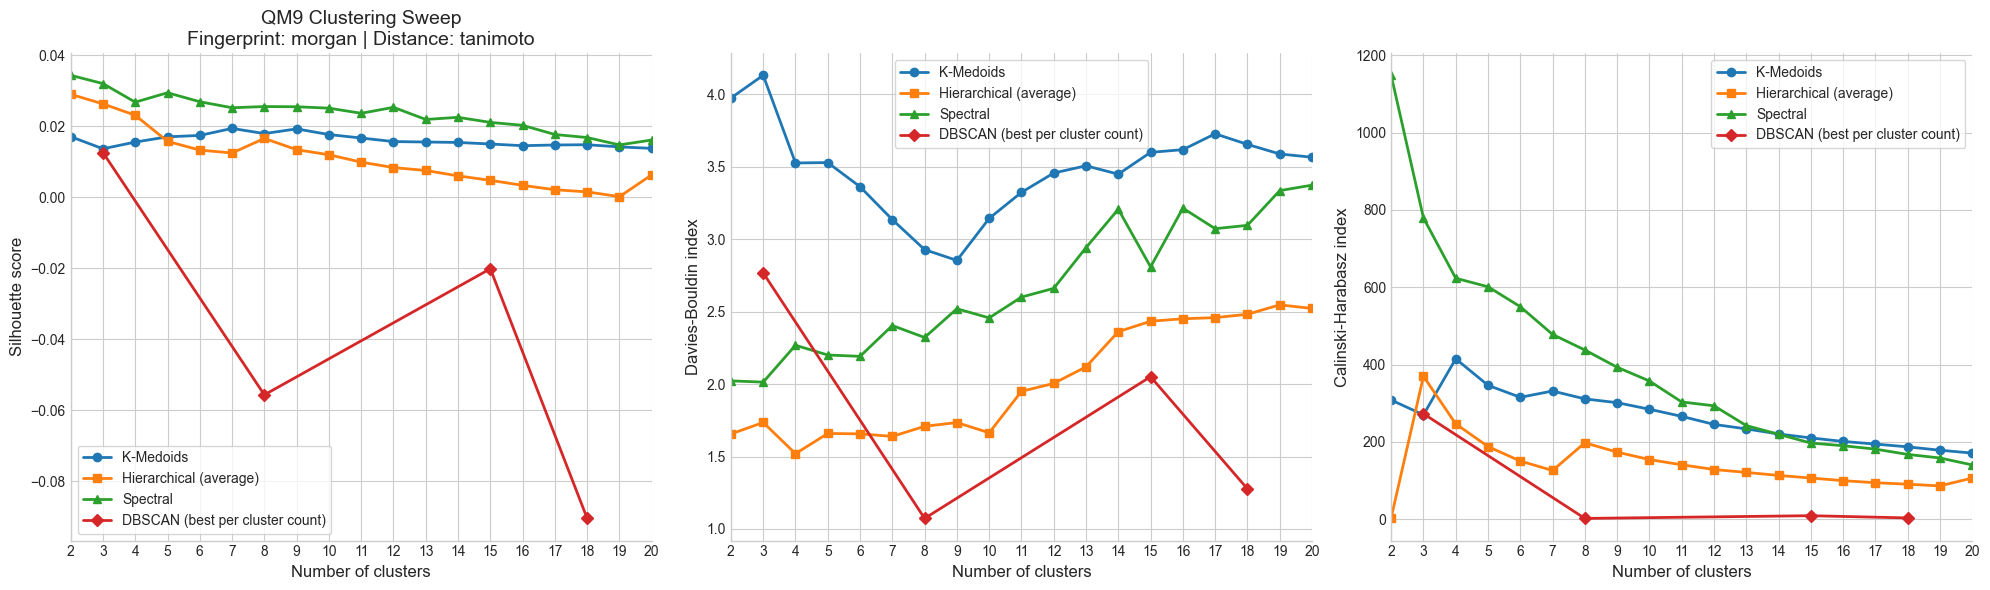

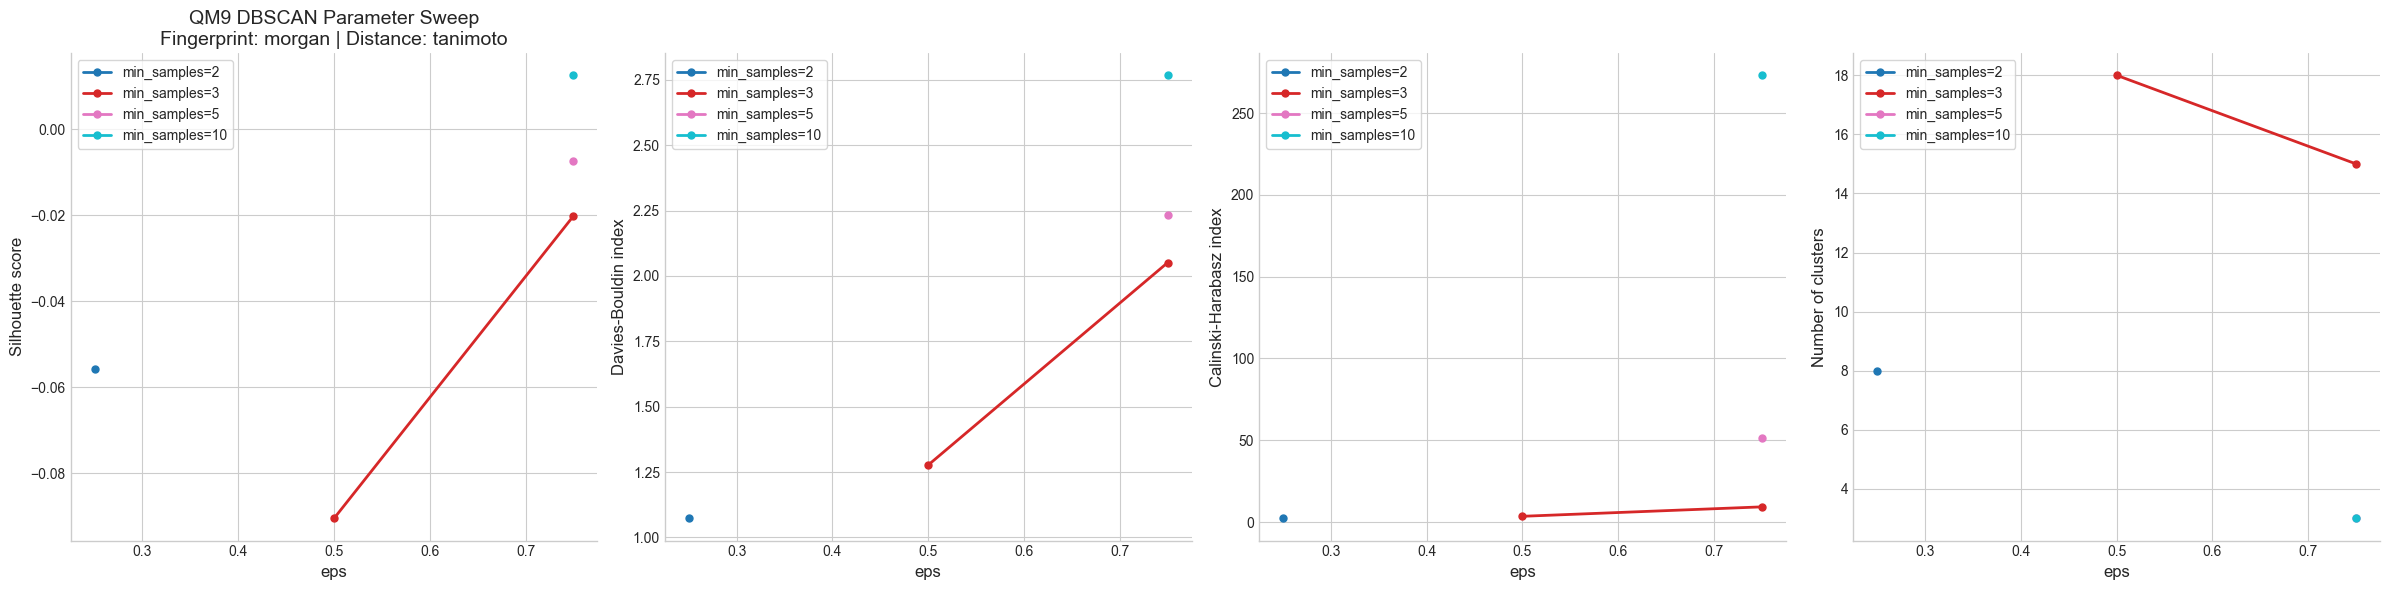

2026-04-15 17:11:43.347 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:840 - Saved clustering sweep plot to figures/qm9/clustering/tanimoto/morgan/clustering_sweep_2_to_20_clusters.png
2026-04-15 17:11:43.348 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:842 - Saved DBSCAN evaluation plot to figures/qm9/clustering/tanimoto/morgan/dbscan_parameter_sweep.png
2026-04-15 17:11:43.348 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:843 - Saved clustering sweep results to figures/qm9/clustering/tanimoto/morgan/clustering_sweep_2_to_20_clusters.json


In [9]:
out = evaluate_distance_matrix_clustering_sweep(
    dist_matrix=dist_matrix,
    fingerprint="morgan",
    distance_metric="tanimoto",
    dataset_name="qm9",
)

# Hiercical Clustering on Distance Matrix

In [20]:
model_hier = AgglomerativeClustering(metric='precomputed', n_clusters=3, linkage='average')
labels_hier = model_hier.fit_predict(dist_matrix)
df = df.with_columns(labels_hier=labels_hier)
print(np.unique(labels_hier, return_counts=True))

(array([0, 1, 2]), array([ 938,    5, 4057]))


In [21]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [22]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="morgan",
    distance_metric="tanimoto",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

2026-04-17 10:14:54.042 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/tanimoto/morgan/pca_hierarchical_projection.png


{'coords': array([[ 1.21527925,  1.71274172],
        [ 1.98816896, -1.69302976],
        [-0.2607709 , -0.32863902],
        ...,
        [ 2.57937249, -1.84158736],
        [-0.4344677 , -0.38770645],
        [ 2.69716913, -1.57512399]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/tanimoto/morgan/pca_hierarchical_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/tanimoto/morgan'),
 'clustering_method': 'hierarchical'}

In [23]:
average_numeric_by_cluster(df, "labels_hier")

labels_hier,count,token_to_atom_ratio,num_atoms,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_km,labels_spectral,pct_aliphatic_ring,pct_aromatic,pct_acyclic
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,938,1.862363,15.585288,121.782516,0.229211,49.892324,0.671086,12.964864,8.778252,1.260128,0.929638,2.033214,2.025586,0.035884,0.658612,0.305504,1.030917,2.872068,6.098081,0.212154,3.39339,1.707889,6.34435,29.316631,1.259139,0.015991,0.113006,0.175906,0.242004,0.037313,0.0,0.02452,0.022388,0.234542,0.015991,3.464819,3.104825,72.444392,-6.14693,-0.349829,5.797133,1143.219847,3.316243,-11505.440162,-11505.224837,-11505.199167,-11506.33467,29.06617,-68.072215,-68.457573,-68.832413,-63.475686,3.903549,1.444652,1.047985,1.157783,0.001066,11.727079,88.272921,0.0
1,5,2.1717,18.6,104.8,1.0,10.8,0.967794,12.821829,7.4,1.4,0.0,2.0401,0.0,0.0,0.057143,0.942857,0.0,1.2,6.2,0.0,0.4,5.8,5.4,40.4,1.253312,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.2,0.0,1.2,0.82556,68.16,-6.837133,1.986975,8.824653,819.3302,4.540443,-9064.377832,-9064.192773,-9064.16709,-9065.214746,26.5914,-75.626142,-76.15788,-76.610278,-70.273891,3.732526,2.92259,1.857912,1.4,0.0,100.0,0.0,0.0
2,4057,2.13382,18.593049,123.048558,0.065319,33.767069,0.897557,12.829491,8.789007,1.728617,0.008381,2.066645,2.373675,0.071287,0.138372,0.790342,0.893024,1.829184,6.604387,0.473996,0.845945,5.235642,6.356175,39.841509,1.26328,0.0,0.39019,0.000739,0.104757,0.147153,0.002218,0.042889,0.146167,0.585408,0.0,2.233424,2.600288,75.80649,-6.62572,0.449962,7.075683,1203.457074,4.228471,-11107.42893,-11107.19377,-11107.168095,-11108.34287,32.2728,-77.980447,-78.461892,-78.914075,-72.547039,3.290189,1.389039,1.1323,1.084545,0.000493,86.295292,0.838058,12.86665


# KMedoids

In [14]:
model_km = KMedoids(n_clusters=3, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
df = df.with_columns(labels_km=labels_km)

In [15]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [16]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="morgan",
    distance_metric="tanimoto",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_km,
    clustering_method="kmedoids"
)

2026-04-17 08:42:17.935 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/tanimoto/morgan/pca_kmedoids_projection.png


{'coords': array([[ 1.21527925,  1.71274172],
        [ 1.98816896, -1.69302976],
        [-0.2607709 , -0.32863902],
        ...,
        [ 2.57937249, -1.84158736],
        [-0.4344677 , -0.38770645],
        [ 2.69716913, -1.57512399]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/tanimoto/morgan/pca_kmedoids_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/tanimoto/morgan'),
 'clustering_method': 'kmedoids'}

In [30]:
average_numeric_by_cluster(df, "labels_km")

labels_km,count,token_to_atom_ratio,num_atoms,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,pct_aliphatic_ring,pct_aromatic,pct_acyclic
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,1753,2.058317,17.03822,122.232744,0.12607,39.030804,0.812045,12.880998,8.764974,1.782658,0.344552,2.08066,1.576155,0.020005,0.373227,0.606768,0.780947,2.223617,6.631489,0.121506,2.02567,3.851683,6.043354,35.442099,1.268329,0.007986,0.098118,0.060468,0.167712,0.140901,0.00057,0.077581,0.20308,0.577867,0.008557,2.766115,2.936693,73.153109,-6.403933,-0.014655,6.389314,1087.257248,3.775883,-11293.165303,-11292.951011,-11292.925341,-11294.052671,29.654072,-73.149836,-73.592231,-74.004433,-68.136047,3.354026,1.576309,1.196856,0.684541,67.883628,32.059327,0.057045
1,1370,2.096464,18.375182,121.360584,0.129927,30.521898,0.871361,12.781793,8.80146,1.821168,0.057664,2.072957,2.160584,0.163904,0.091331,0.744765,0.993431,1.574453,6.305839,1.108029,0.591241,5.2,6.436496,38.809489,1.2628,0.0,0.463504,0.013869,0.094161,0.050365,0.00146,0.008029,0.053285,0.358394,0.0,1.90219,2.422408,77.736336,-6.602805,0.698822,7.301613,1185.257993,4.152005,-10705.283206,-10705.048185,-10705.022518,-10706.190958,32.645936,-77.718859,-78.192068,-78.638649,-72.344467,3.307396,1.399219,1.15072,0.140146,82.773723,5.693431,11.532847
2,1877,2.096045,18.701119,124.361215,0.045818,39.216835,0.883553,12.883831,8.793287,1.375599,0.118807,2.03217,3.093767,0.033698,0.213131,0.753171,0.990943,2.166223,6.542888,0.208311,1.201918,4.792754,6.581247,39.445392,1.256819,0.000533,0.469899,0.022909,0.122003,0.168354,0.003197,0.026638,0.098562,0.584443,0.0,2.590304,2.663347,75.175487,-6.610876,0.306657,6.917529,1294.137885,4.25193,-11420.941482,-11420.696777,-11420.671094,-11421.87484,32.828583,-77.725115,-78.201158,-78.656121,-72.275168,3.525705,1.238588,1.018363,0.261055,68.833245,11.827384,19.339371


# Spectral

In [17]:
model_spectral = SpectralClustering(
                n_clusters=3,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(dist_matrix)
df = df.with_columns(labels_spectral=labels_spectral)
print(np.unique(labels_spectral, return_counts=True))

(array([0, 1, 2], dtype=int32), array([4998,    1,    1]))


In [24]:
create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [49]:
labels_km

array([0, 2, 1, ..., 2, 2, 2], shape=(5000,), dtype=uint64)

In [18]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="morgan",
    distance_metric="tanimoto",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_spectral,
    clustering_method="spectral"
)

2026-04-17 08:49:48.748 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/tanimoto/morgan/pca_spectral_projection.png


{'coords': array([[ 1.21527925,  1.71274172],
        [ 1.98816896, -1.69302976],
        [-0.2607709 , -0.32863902],
        ...,
        [ 2.57937249, -1.84158736],
        [-0.4344677 , -0.38770645],
        [ 2.69716913, -1.57512399]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/tanimoto/morgan/pca_spectral_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/tanimoto/morgan'),
 'clustering_method': 'spectral'}

In [19]:
average_numeric_by_cluster(df, "labels_spectral")

labels_spectral,count,token_to_atom_ratio,num_atoms,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,pct_aliphatic_ring,pct_aromatic,pct_acyclic
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,4998,2.08302,18.029412,122.794518,0.096839,36.770108,0.855166,12.854822,8.785714,1.640656,0.181072,2.060371,2.306523,0.06456,0.235822,0.699618,0.918167,2.02421,6.509404,0.42437,1.323129,4.57483,6.352941,37.869748,1.262488,0.003001,0.337735,0.033613,0.130452,0.126451,0.001801,0.039416,0.122849,0.520408,0.003001,2.463385,2.693401,75.169104,-6.53571,0.301639,6.837356,1191.783601,4.057804,-11180.138482,-11179.907082,-11179.881407,-11181.048715,31.666954,-76.121031,-76.584512,-77.022203,-70.844529,3.405078,1.4011,1.11727,0.37615,1.098439,72.328932,17.226891,10.444178
1,1,1.545455,11.0,123.0,0.0,49.0,0.638198,13.138502,9.0,1.0,1.0,2.0,0.0,0.2,0.8,0.0,0.0,3.0,4.0,1.0,4.0,0.0,6.0,17.0,1.304038,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,2.9366,67.389999,-7.964772,-2.468073,5.4967,1155.412476,1.827653,-12401.580078,-12401.399414,-12401.374023,-12402.435547,24.056,-55.645657,-55.889771,-56.146702,-52.312183,6.03786,1.02362,0.87524,2.0,1.0,0.0,100.0,0.0
2,1,2.181818,22.0,114.0,1.0,20.0,0.94794,12.855371,8.0,1.0,0.0,2.0,2.0,0.0,0.0,1.0,1.0,1.0,7.0,0.0,0.0,7.0,7.0,48.0,1.246098,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.2696,78.0,-7.110335,2.166026,9.276361,1172.364502,5.510877,-9530.21875,-9529.992188,-9529.966797,-9531.104492,32.279999,-87.982719,-88.603767,-89.143585,-81.631775,3.87012,1.30822,1.05298,0.0,2.0,100.0,0.0,0.0


# DBSCAN 

In [47]:
model_db = DBSCAN(
    eps=0.7,
    min_samples=8,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db, return_counts=True))

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]), array([2730, 2173,    8,    7,   25,   13,    4,    7,    7,    4,    8,
          3,    1,   10]))


In [48]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [49]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="morgan",
    distance_metric="tanimoto",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_db,
    clustering_method="dbscan"
)

2026-04-17 10:26:59.203 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/tanimoto/morgan/pca_dbscan_projection.png


{'coords': array([[ 1.21527925,  1.71274172],
        [ 1.98816896, -1.69302976],
        [-0.2607709 , -0.32863902],
        ...,
        [ 2.57937249, -1.84158736],
        [-0.4344677 , -0.38770645],
        [ 2.69716913, -1.57512399]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/tanimoto/morgan/pca_dbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/tanimoto/morgan'),
 'clustering_method': 'dbscan'}

In [54]:
clusters = average_numeric_by_cluster(df, "labels_db")
clusters.show(limit=25)

labels_db,count,token_to_atom_ratio,num_atoms,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,pct_aliphatic_ring,pct_aromatic,pct_acyclic
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
-1,2730,2.064239,17.415018,122.705495,0.04652,37.669231,0.806711,12.874629,8.817582,1.70989,0.311355,2.068081,1.903663,0.053442,0.341414,0.605143,0.964835,2.088278,6.62381,0.348718,1.901099,3.929304,6.377289,36.335165,1.263231,0.005495,0.212454,0.055311,0.165934,0.116484,0.002198,0.034799,0.097802,0.446886,0.002198,2.638462,2.739783,75.198015,-6.388279,0.083799,6.472089,1181.377978,3.876712,-11204.252573,-11204.030594,-11204.004921,-11205.153355,30.517366,-74.328079,-74.7773,-75.19919,-69.214215,3.611678,1.419412,1.107277,1.354945,1.10989,0.000366,64.395604,29.52381,6.080586
0,2173,2.110237,18.862862,123.039577,0.162908,35.158767,0.921899,12.826115,8.754257,1.565117,0.0,2.051684,2.813162,0.078832,0.094161,0.827007,0.837552,1.938794,6.368155,0.52278,0.557754,5.454671,6.337782,39.985274,1.261868,0.0,0.503912,0.0,0.079613,0.139899,0.001381,0.04694,0.156006,0.624482,0.0,2.219052,2.627782,75.252163,-6.736097,0.578126,7.314219,1209.105198,4.302897,-11155.660142,-11155.416696,-11155.39102,-11156.582566,33.162153,-78.616803,-79.100362,-79.559485,-73.117886,3.151344,1.369506,1.128195,1.996318,1.083755,0.00092,83.801197,0.0,16.198803
1,8,2.184432,19.375,115.0,0.875,17.5,0.923576,12.79947,8.25,2.125,0.0,2.11854,0.125,0.0,0.066964,0.933036,0.25,1.25,7.125,0.0,0.5,6.375,5.625,42.5,1.268884,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.375,1.925375,74.415001,-6.81237,1.3854,8.19777,1016.59304,4.625864,-9911.228882,-9911.02417,-9910.998474,-9912.106628,28.808125,-79.874358,-80.416403,-80.888707,-74.245645,4.394982,1.575354,1.4698,2.0,1.5,0.0,100.0,0.0,0.0
2,7,2.273554,18.285714,118.571429,-1.428571,36.0,0.694809,12.932034,8.571429,2.428571,0.0,2.151291,1.285714,0.093197,0.047619,0.859184,2.0,1.428571,7.428571,0.571429,0.285714,5.428571,5.857143,41.714286,1.26452,0.0,0.285714,0.0,0.285714,0.0,0.0,0.0,0.0,0.0,0.0,2.285714,2.320686,75.011429,-6.386901,1.280879,7.668168,1053.566162,4.205496,-10234.983817,-10234.76995,-10234.74428,-10235.859375,30.605715,-75.108627,-75.59944,-76.043726,-69.745596,3.690946,1.508627,1.329971,2.0,0.285714,0.0,100.0,0.0,0.0
3,25,1.90138,16.64,120.56,0.24,60.28,0.651319,13.006121,8.64,1.04,1.0,2.004706,2.92,0.008,0.728857,0.263143,2.28,2.24,7.08,0.04,3.8,1.44,5.96,31.72,1.241832,0.0,0.04,0.48,0.76,0.04,0.0,0.0,0.04,0.08,0.04,3.36,2.905684,74.3108,-5.299036,0.533996,5.83325,1121.023479,3.65797,-11192.530664,-11192.289453,-11192.263789,-11193.444492,32.19224,-71.188403,-71.588564,-71.990531,-66.320844,2.84895,1.654186,1.050963,0.0,1.04,0.0,0.0,100.0,0.0
4,13,1.836327,15.461538,115.615385,0.153846,48.538462,0.679323,12.96216,8.307692,1.0,1.0,2.0,2.692308,0.025641,0.663919,0.31044,1.538462,2.230769,5.923077,0.153846,3.307692,1.615385,6.0,28.615385,1.248583,0.0,0.153846,0.384615,0.0,0.076923,0.0,0.0,0.230769,0.153846,0.0,3.230769,2.443731,68.334616,-6.127376,0.123916,6.251293,1043.30657,3.347488,-10834.34683,-10834.129357,-10834.103516,-10835.243314,28.887615,-66.706728,-67.08507,-67.45674,-62.200525,3.508057,1.801428,1.176598,0.0,1.692308,0.0,0.0,100.0,0.0
5,4,1.849925,16.0,117.0,-0.5,28.25,0.883093,12.74159,8.5,0.0,0.0,1.875427,3.25,0.47619,0.16071

# KMeans on embedding

In [ ]:
df

mol_id,formula,smiles,canonical_smiles,selfies,functional_groups,num_atoms,structure_class,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,morgan_fingerprint,labels_hier,labels_km,labels_spectral,labels_db
str,str,str,str,str,str,i64,str,i64,i64,i64,f64,f64,i64,i64,i64,f64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[i8],i64,u64,i32,i64
"""qm9_89""","""C3H5NO""","""[H]N1C([H])([H])C(=O)C1([H])[H…","""[H]N1C([H])([H])C(=O)C1([H])[H…","""[H][N][C][Branch1][C][H][Branc…","""ketone""",10,"""Aliphatic Ring""",71,0,29,0.761845,12.992522,5,1,0,2.0,0,0.0,0.333333,0.666667,1,2,4,0,1,2,4,20,1.261328,0,0,0,0,0,0,0,1,0,0,2,2.5257,39.34,-6.631414,-0.702054,5.929361,359.152008,2.167387,-6726.387695,-6726.26123,-6726.235352,-6727.135742,16.083,-40.819069,-41.077904,-41.309227,-38.114258,11.54185,4.90368,3.63309,"[0, 0, … 0]",2,0,0,-1
"""qm9_132""","""C4H10O""","""[H]C([H])([H])C([H])([H])OC([H…","""[H]C([H])([H])C([H])([H])OC([H…","""[H][C][Branch1][C][H][Branch1]…","""ether""",15,"""Acyclic""",74,1,9,0.936769,12.976237,5,0,0,1.866667,4,0.0,0.0,1.0,0,1,4,0,0,4,6,31,1.209514,0,0,0,0,0,0,0,0,1,0,1,0.9301,50.619999,-6.756587,2.53338,9.289967,631.081787,3.704885,-6355.161621,-6354.975098,-6354.949219,-6355.981445,22.881001,-56.966496,-57.358181,-57.718079,-52.897472,17.9608,2.23958,2.09578,"[0, 0, … 0]",2,1,0,-1
"""qm9_139""","""C3H4N2""","""[H]N1C([H])([H])[C@]1([H])C#N""","""[H]N1C([H])([H])[C@]1([H])C#N""","""[H][N][C][Branch1][C][H][Branc…","""""",9,"""Aliphatic Ring""",68,0,45,0.444793,13.026985,5,1,0,2.0,0,0.333333,0.0,0.666667,1,2,3,1,0,2,4,17,1.264596,0,0,0,0,0,0,0,0,0,0,2,2.8377,40.209999,-7.55116,0.206807,7.757967,386.555695,1.880987,-6152.69043,-6152.564453,-6152.538574,-6153.435547,15.572,-38.04356,-38.264439,-38.47002,-35.623112,17.103571,3.50921,3.35299,"[0, 0, … 0]",2,1,0,-1
"""qm9_144""","""C3H5NO""","""[H]C(=O)N1C([H])([H])C1([H])[H…","""[H]C(=O)N1C([H])([H])C1([H])[H…","""[H][C][=Branch1][C][=O][N][C][…","""amide""",10,"""Aliphatic Ring""",71,0,20,0.761845,12.992522,5,1,0,2.0,0,0.0,0.333333,0.666667,0,1,4,0,1,2,4,20,1.261934,0,0,0,0,1,0,0,0,0,0,2,3.2517,40.77,-6.952509,-0.035375,6.917135,383.601288,2.16589,-6726.451172,-6726.317871,-6726.291992,-6727.207031,16.197001,-40.882473,-41.134586,-41.36591,-38.185608,14.7497,3.94953,3.42803,"[0, 0, … 1]",2,2,0,-1
"""qm9_149""","""C4H8O""","""[H]OC([H])([H])C1([H])C([H])([…","""[H]OC([H])([H])C1([H])C([H])([…","""[H][O][C][Branch1][C][H][Branc…","""alcohol""",13,"""Aliphatic Ring""",72,0,20,0.964858,12.880514,5,1,0,2.0,2,0.0,0.0,1.0,1,1,4,0,0,4,5,27,1.240861,0,1,0,0,0,0,0,0,0,0,1,1.3201,46.009998,-7.077682,2.1497,9.224659,468.622894,3.110261,-6321.884277,-6321.729004,-6321.703125,-6322.664062,20.059,-50.915638,-51.26128,-51.569748,-47.386292,12.75002,3.20516,2.88061,"[0, 0, … 0]",2,1,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""qm9_130677""","""C4H5F3O2""","""[H]C(=O)O[C@]([H])(C([H])([H])…","""[H]C(=O)O[C@]([H])(C([H])([H])…","""[H][C][=Branch1][C][=O][O][C@]…","""ether,halogen""",14,"""Acyclic""",142,1,26,1.567518,13.752707,9,0,0,1.857143,2,0.0,0.25,0.75,0,2,4,0,1,3,5,28,1.279761,0,0,0,0,0,0,0,0,1,0,5,3.6403,52.540001,-7.93484,-0.185037,7.752524,1188.842651,2.583122,-16472.59375,-16472.349609,-16472.324219,-16473.541016,31.017,-59.400204,-59.694172,-60.02824,-55.291012,2.60612,1.14569,0.95669,"[0, 1, … 0

In [ ]:
embedding = np.array(df['morgan_fingerprint'].to_list())
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(embedding)
df = df.with_columns(kmeans_labels=kmeans_labels)

In [ ]:
create_chemiscope_viewer(df, embedding, kmeans_labels, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…